In [1]:
import sys

sys.path.append("../")
from explainerpfn.base import ExplainerPFN
from explainerpfn.train.synthetic_data import SyntheticDataGenerator
import torch
from torch import optim
from tqdm.auto import tqdm
import numpy as np

In [2]:
datasets = SyntheticDataGenerator(successor_as_target=True)
datasets.load_data(path="synthetic_data.pkl")

# Keep only datasets with 10 features or less - for testing purposes
desc = datasets.describe()
desc = desc[desc["n_features"] <= 11]
datasets_idxs = desc.index.tolist()

# Get iterator for datasets
data = list(zip(datasets.X_, datasets.y_pred_, datasets.explanations_))
data = [data[i] for i in datasets_idxs]

# Load model to train
xai = ExplainerPFN(model_path="../../test_explainerpfn_model.ckp", random_state=42)

In [ ]:
import matplotlib.pyplot as plt

random_state = None

# Create a new ExplainerPFN for the feature we want to finetune
xai = ExplainerPFN(
    fit_mode="low_memory",
    model_path="../../test_explainerpfn_model.ckp",
    random_state=random_state,
)
xai._initialize_model_variables()

# Setup optimizer - using Adam with a relatively small learning rate
# NOTE: Probably use lr=1e-5
optimizer = optim.Adam(xai.model_.parameters(), lr=1e-5)
rng = np.random.default_rng(random_state)

# Training parameters
num_epochs = 100
num_batches = 2

# Training loop
losses = []
for epoch in tqdm(range(num_epochs), desc="Epochs"):

    # Zero gradients once per epoch
    optimizer.zero_grad()

    # Shuffle indices for each epoch
    epoch_losses = []
    batch_idxs = rng.choice(np.arange(len(data)), size=num_batches, replace=False)

    # Collect logits and SHAP values from all batches
    all_logits = []
    all_shap_values = []
    all_batch_losses = []

    # Process all batches
    for batch_idx in batch_idxs:
        X_train, y_train, shap_train = data[batch_idx]

        indices = rng.permutation(len(X_train))
        feature_name = rng.choice(shap_train.columns[shap_train.nunique() > 1])
        feature_idx = shap_train.columns.get_loc(feature_name)

        # Get batch data
        X_batch = X_train.values[indices]
        y_batch = y_train[indices]
        shap_batch = shap_train.values[indices]  # Use iloc for proper indexing

        _xai = ExplainerPFN(fit_mode="low_memory", random_state=random_state)
        _xai.fit(X_batch, y_batch)
        _xai.model_ = xai.model_
        _xai.executor_.model = xai.model_
        _xai.executor_.use_torch_inference_mode(False)
        _xai.model_.train()

        # Get logits
        with torch.enable_grad():
            # xai.forward returns a tuple (first element are averaged logits across estimators)
            feature_logits = _xai.forward(
                X_batch, y_batch, feature_idx=feature_idx, only_return_standard_out=True
            )[0]

        # Collect logits and corresponding SHAP values for this batch
        all_logits.append(feature_logits)

        # Get the SHAP values for the selected feature
        batch_shap_values = shap_batch[:, feature_idx]
        batch_shap_tensor = torch.tensor(batch_shap_values, dtype=torch.float32).to(
            xai.device_
        )
        # all_shap_values.append(batch_shap_tensor)

        # Get the bardist loss for this batch
        batch_loss_per_sample = _xai.bardist_(feature_logits.T, batch_shap_tensor)
        all_batch_losses.append(batch_loss_per_sample)

    # Concatenate all batch results
    # logits = torch.cat(all_logits, dim=1)  # Concatenate along the sequence dimension
    # shap_tensor = torch.cat(all_shap_values, dim=0)  # Concatenate along batch dimension
    all_batch_losses_tensor = torch.cat(
        all_batch_losses, dim=0
    )  # Concatenate along batch dimension

    # Compute the loss for all batches combined
    # loss_per_sample = xai.bardist_(logits.T, shap_tensor)

    # Compute mean loss across all samples from all batches
    loss = all_batch_losses_tensor.mean()

    # Backpropagate once per epoch (after processing all batches)
    loss.backward()
    optimizer.step()

    # Record loss
    losses.append(loss.item())

    # Print progress
    # if epoch % 5 == 0 or epoch == num_epochs - 1:
    print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    # Save the finetuned model periodically
    # if epoch % 10 == 0 or epoch == num_epochs - 1:
    xai.save_foundation_model("../../test_explainerpfn_model.ckp")

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0, Loss: -1.964663
Epoch 1, Loss: -1.047252
Epoch 2, Loss: 2.336032
Epoch 3, Loss: -0.205232
Epoch 4, Loss: -0.679172
Epoch 5, Loss: -0.342986
Epoch 6, Loss: 0.478063
Epoch 7, Loss: -0.971839
Epoch 8, Loss: -1.581578
Epoch 9, Loss: 0.356258
Epoch 10, Loss: -0.562978
Epoch 11, Loss: -0.470981
Epoch 12, Loss: -1.327804
Epoch 13, Loss: -0.711449
Epoch 14, Loss: -1.631428
Epoch 15, Loss: 0.610226
Epoch 16, Loss: -0.497329


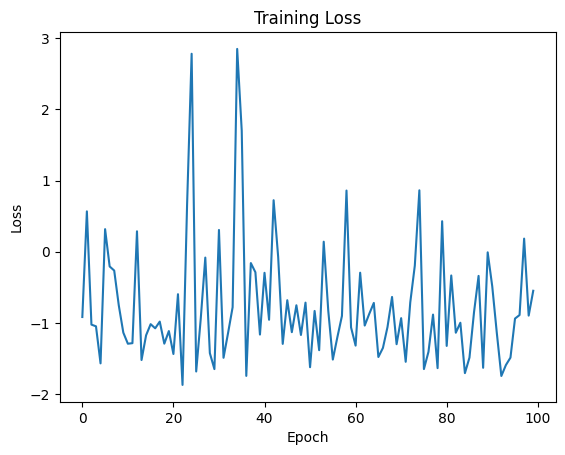

In [ ]:
import matplotlib.pyplot as plt

losses = input()
epochs = [int(x.split(", Loss: ")[0].strip()) for x in losses.split("Epoch") if x]
losses = [float(x.split(", Loss: ")[-1].strip()) for x in losses.split("Epoch") if x]

plt.plot(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
model = LinearRegression()
model.fit(np.arange(len(losses)).reshape(-1, 1), np.array(losses))
trendline = model.predict(np.arange(len(losses)).reshape(-1, 1))
model.coef_, model.intercept_

(array([-0.00362268]), np.float64(-0.5847061396039606))

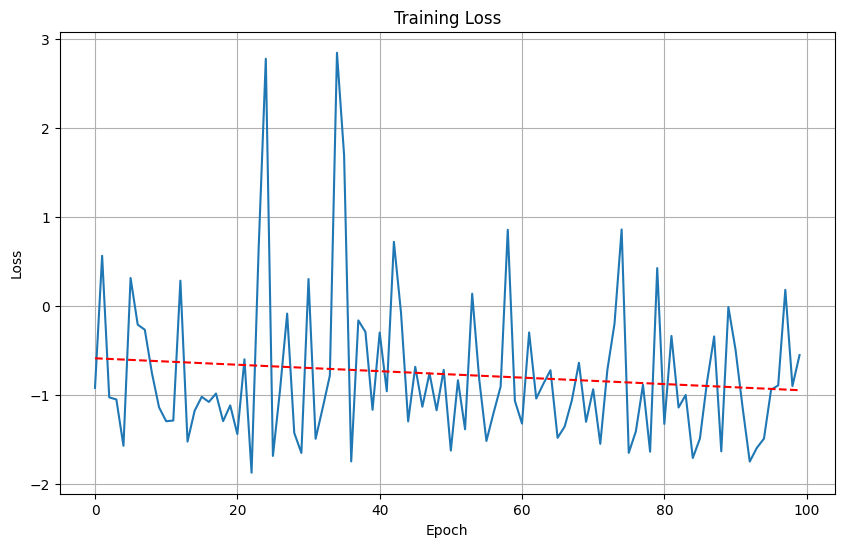

In [ ]:
# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.plot(trendline, linestyle='--', color='red', label='Trendline')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

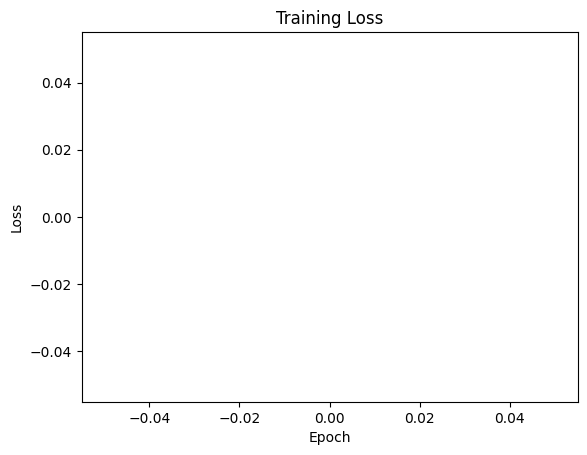

In [ ]:
import matplotlib.pyplot as plt

losses = input()
epochs = [int(x.split(", Loss: ")[0].strip()) for x in losses.split("Epoch") if x]
losses = [float(x.split(", Loss: ")[-1].strip()) for x in losses.split("Epoch") if x]

plt.plot(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [ ]:
[int(x.split(", Loss: ")[0].strip()) for x in losses.split("Epoch") if x]

AttributeError: 'list' object has no attribute 'split'

In [ ]:
# _xai.bardist_(feature_logits.T, batch_shap_tensor)
feature_logits
batch_shap_tensor

tensor([ 0.0276, -0.0355,  0.0000,  0.0000])

In [ ]:
feature_logits.shape

torch.Size([5000, 391])